In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kritikseth/fruit-and-vegetable-image-recognition")

print("Path to dataset files:", path)

100%|██████████| 1.98G/1.98G [00:50<00:00, 42.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8


In [2]:
import os

In [3]:
os.listdir(path)

['train', 'test', 'validation']

In [7]:
train_path = os.path.join(path,"train")
test_path = os.path.join(path, "test")
valid_path = os.path.join(path, "validation")

In [8]:
print(train_path)
print(test_path)
print(valid_path)

/root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/train
/root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/test
/root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/validation


In [22]:
cocumber = os.path.join(train_path, "cucumber")
cocumber

'/root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/train/cucumber'

In [24]:
os.listdir(cocumber)[7]

'Image_59.png'

In [27]:
cocumber_image_path = os.path.join(cocumber,os.listdir(cocumber)[2])
cocumber_image_path

'/root/.cache/kagglehub/datasets/kritikseth/fruit-and-vegetable-image-recognition/versions/8/train/cucumber/Image_58.jpg'

In [28]:
from PIL import Image
import cv2

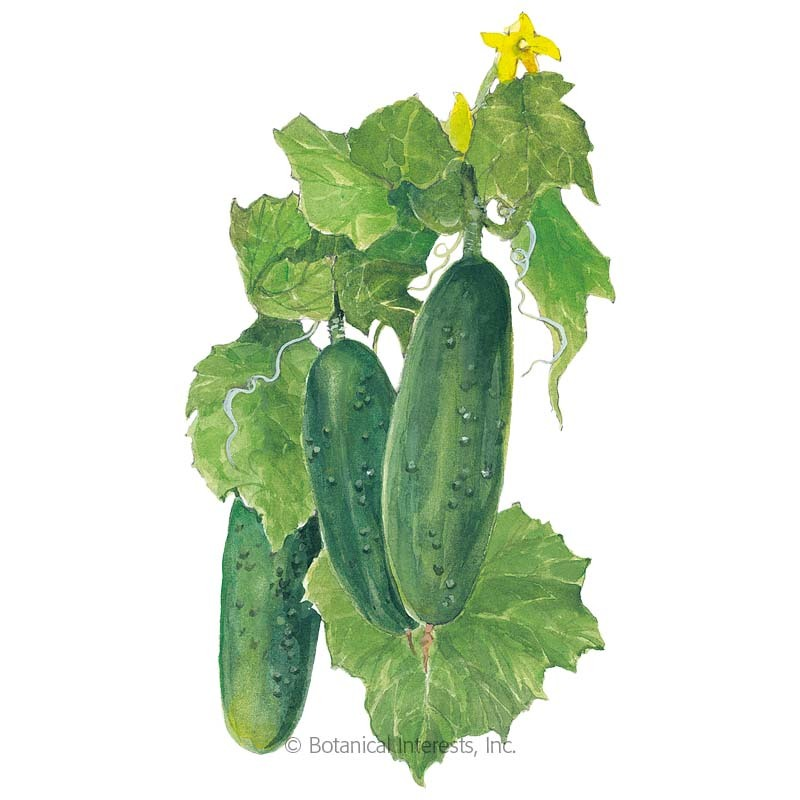

In [29]:
Image.open(cocumber_image_path)

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]], dtype=uint8)
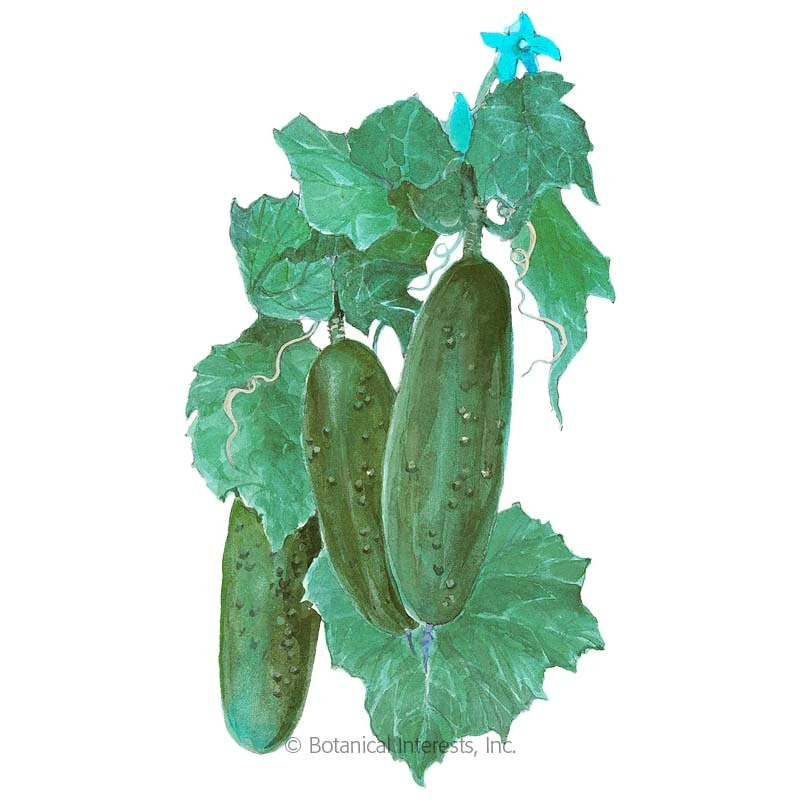

In [31]:
cv2.imread(cocumber_image_path)

In [32]:
import tensorflow as tf


In [34]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(180,180),
    batch_size=32,
    shuffle = True,

)

Found 3115 files belonging to 36 classes.


In [36]:
len(train_data.class_names)

36

In [37]:
test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(180,180),
    batch_size=32,
    shuffle = False,

)

Found 359 files belonging to 36 classes.


In [38]:
valid_data = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=(180,180),
    batch_size=32,
    shuffle = True,

)

Found 351 files belonging to 36 classes.


In [40]:
from tensorflow import keras
from tensorflow.keras import layers

In [45]:
model = keras.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3 , padding="same"),
    layers.MaxPool2D(2),
    layers.Conv2D(64, 3 , padding="same"),
    layers.MaxPool2D(2),
    layers.Conv2D(128, 3 , padding="same"),       # acha tareeke sai learn kr lena
    layers.MaxPool2D(2),


    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(36, activation="softmax")    #  classify krna




])

In [46]:
model.compile(optimizer="adam", loss = "sparse_categorical_crossentropy", metrics=["accuracy"])

In [47]:
model.fit(train_data, validation_data=valid_data,epochs=10)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 66s 626ms/step - accuracy: 0.1047 - loss: 3.4549 - val_accuracy: 0.2707 - val_loss: 2.6136
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 76s 591ms/step - accuracy: 0.2607 - loss: 2.5880 - val_accuracy: 0.4986 - val_loss: 1.8725
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 83s 602ms/step - accuracy: 0.4199 - loss: 2.0086 - val_accuracy: 0.7094 - val_loss: 1.2343
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 609ms/step - accuracy: 0.5958 - loss: 1.3934 - val_accuracy: 0.8462 - val_loss: 0.7018
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 88s 681ms/step - accuracy: 0.7644 - loss: 0.7783 - val_accuracy: 0.9202 - val_loss: 0.4239
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 615ms/step - accuracy: 0.9056 - loss: 0.3327 - val_accuracy: 0.9288 - val_loss: 0.3411
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 60s 618ms/step - accuracy: 0.9522 - loss: 0.1806 - val_accuracy: 0.9487 - val_loss: 0.3248
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 61s 616ms/step - accuracy: 0.9775 - loss: 0.1098 - val_accu

In [48]:
model.save("Fruit_veg.keras")

In [58]:
import gradio as gr
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
def pred_image(img):

  img = load_img(img, target_size=(180, 180))
  img = img_to_array(img)
  img = np.expand_dims(img, axis = 0)
  pred = model.predict(img)
  score = tf.nn.softmax(pred)
  prediction  = train_data.class_names[np.argmax(score)]

  confidence = np.max(score)
  return prediction
  return confidence

In [59]:
app = gr.Interface(fn = pred_image, inputs=gr.Image(type="filepath"), outputs="text")

In [60]:
app.launch(show_error=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://81d687f33f151e4fbc.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [61]:
train_data.class_names

['apple',
 'banana',
 'beetroot',
 'bell pepper',
 'cabbage',
 'capsicum',
 'carrot',
 'cauliflower',
 'chilli pepper',
 'corn',
 'cucumber',
 'eggplant',
 'garlic',
 'ginger',
 'grapes',
 'jalepeno',
 'kiwi',
 'lemon',
 'lettuce',
 'mango',
 'onion',
 'orange',
 'paprika',
 'pear',
 'peas',
 'pineapple',
 'pomegranate',
 'potato',
 'raddish',
 'soy beans',
 'spinach',
 'sweetcorn',
 'sweetpotato',
 'tomato',
 'turnip',
 'watermelon']